<a href="https://colab.research.google.com/github/eduardodpms/UnB_Notebooks/blob/main/25.2%20TEMA/Trabalho%203%20(Final)/tema3_2025_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Trabalho Final - *TEMA 2025/2***

## **Universidade de Brasília** - *Faculdade de Ciências e Tecnologias em Engenharia*

## *Terceiro Trabalho de Tópicos Especiais em Matemática Aplicada - 2025/2*

- Docente: Vinícius de Carvalho Rispoli

- Discente: Eduardo de Pina Moreira Santos

- Matrícula: 231034494

## **Sumário**

1. [***Introdução***](#1.)
2. [***Metodologia***](#2.)
3. [***Análise e Pré-Processamento do Dataset***](#3.)
4. [***Processamento do Dataset***](#4.)
5. [***Modelo Transformador***](#5.)
6. [***Avaliação e Resultados***](#6.)
7. [***Conclusão***](#7.)
8. [***Referências***](#8.)

<a name="1."></a>
## **1. Introdução**

Este trabalho corresponde ao projeto desenvolvido para a última atividade avaliativa da disciplina de *Tópicos Especiais em Matemática Aplicada* na **UnB**. Nesse sentido, a fim de desenvolver o conhecimento dos estudantes no que tange a modelos de linguagem utilizando o *Pytorch*, foi proposto que eles aplicassem uma rede neural em um contexto real, de forma original.

Nesse sentido, foi elaborado um projeto para um modelo básico de detecção de utilização de IA's generativas na construção de textos longos (redações) em inglês. Para isso, foi selecionado o *Dataset* **LLM - Detect AI Generated Text Dataset** [¹](#8.), disponível no [*kaggle*](https://www.kaggle.com), contendo cerca de 27.000 textos acompanhados de um booleano indicando o uso de IA ou não em sua construção.

Antes de iniciar esse desenvolvimento, foi elaborada a metodologia a ser seguida no projeto, definida no tópico [*2. Metodologia*](#2.).

<a name="2."></a>
## **2. Metodologia**

A primeira etapa do desenvolvimento do projeto consistiu na elaboração de uma metodologia "parcial" eficiente, para ser seguida no contexto do problema. Essa metodologia pôde ser dividida em **6 fases** principais, listadas e descritas abaixo:

### 1. *Brainstorming e Viabilidade*

- A fase inicial consistiu em um extenso *brainstorming* sobre ideias que cativavam a curiosidade e se envolviam com os tópicos abordados na disciplina. Depois de selecionada uma pequena quantidade de sugestões, seguiu-se para uma pesquisa de *Datasets* que poderiam se encaixar nessas ideias e que não apresentassem a necessidade de desenvolver um projeto com complexidade muito extensa. Assim, selecionou-se o tema sobre o qual seria realizado o trabalho.


### 2. *Pesquisa e Levantamento de Informações*

- Seguindo a etapa de *brainstorming*, foi feita uma busca extensiva de dados na *internet*, em veículos acadêmicos e em *chatbots*, com o intuido de separar e organizar as ferramentas mais adequadas para o projeto, além de uma série de outras informações para o ampliar o conhecimento e proporcionar um desenvolvimento mais limpo e mais consciente do trabalho.

### 3. *Entendimento e Processamento do Dataset*

- Depois de selecionadas um conjunto de ferramentas que seriam utilizadas na atividade, iniciou-se o desenvolvimento do código no *Colab*, importando e experimentando com o *Dataset*. Foi feito um pré-processamento, e depois montado um pipeline para o processamento em si, que envolveria uma complexidade um pouco maior em razão do tamanho do conjunto de dados.

### 4. *Montagem e treinamento do Transformador*

- Após a preparação do *Dataset*, prosseguiu-se para a elaboração da arquitetura do Transformador que seria utilizado. Essa etapa também envolveu a busca de um modelo pré-treinado na internet, que seria utilizado como *backbone* da rede. Assim, foram feitos diversos testes de treinamento sobre essa arquitetura, tentando encontrar aquela que trouxesse os resultados mais congruentes.

### 5. *Avaliação e Análise de Resultados*

- Após o desenvolvimento bem-sucedido do Transformador, bem como seu treinamento, o próximo passo consistiu na obtenção de métricas de teste, para a elaboração de uma análise mais rica para a atividade. Assim, os resultados desse processo foram observados e analisados, para que fizessem parte de um levantamento de hipóteses na etapa de resultados.

### 6. *Organização do código e divisão dos tópicos*

- Por fim, com o código finalizado, seguiu-se para uma etapa de organização do mesmo, removendo trechos desnecessários e melhorando a visualização, de divisão e separação dos tópicos no notebook e, ao final, de elaboração dos textos explicativos.

<br>

Após a elaboração parcial da **metodologia**, iniciou-se todo o desenvolvimento representado nela. Para acompanhar o resultado desse desenvolvimento, siga para o primeiro tópico prático do trabalho: [*3. Análise e Pré-Processamento do Dataset*](#3.).

<a name="3."></a>
## **3. Análise e Pré-Processamento do Dataset**

Nesse tópico, vamos tratar a abordagem inical do Dataset, compreendendo que tipo de processamento deverá ser feito com seu conteúdo. Para isso, serão desenvolvidos os seguintes subtópicos:

- [***3.1. Importações***](#3.1.);
- [***3.2. Análise***](#3.2.);
- [***3.3. Pré-Processamento***](#3.3.).

<a name="3.1."></a>
### *3.1. Importações*

Nesse tópico, apenas importaremos as **bibliotecas** *Python*, bem como o arquivo compactado contendo o *Dataset* no *Google Drive*.

In [1]:
# Bibliotecas Gerais
from collections import Counter
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from google.colab import data_table
from google.colab import drive
import os, re, unicodedata, zlib, math
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import joblib

# Bibliotecas do Pytorch
import torch
from torch.utils.data import Dataset, DataLoader
from torch import nn

In [2]:
drive.mount('/content/drive') # Monta o disco virtual do Google Drive

!unzip /content/drive/MyDrive/archive.zip > /dev/null # Descompacta o arquivo contendo o .csv

Mounted at /content/drive


In [3]:
data = pd.read_csv(filepath_or_buffer='Training_Essay_Data.csv') # Tranfere o dataset para um DataFrame

data[:] = data.sample(frac=1, random_state=42).reset_index(drop=True) # Embaralha as linhas do DataFrame

O *Dataset* está armazenado em um *DataFrame* embaralhado do `pandas`, com as colunas `text` e `generated`.

<a name="3.2."></a>
### *3.2. Análise*

Aqui, faremos uma breve análise sobre os elementos do nosso *Dataset*, que pode ser consultado na tabela abaixo.

In [4]:
data_table.DataTable(data, num_rows_per_page=3, max_rows=3000)

,text,generated
0,I would agree with Emerson's in this world be ...,0
1,Advice is wonderful and helpful to everyone. S...,0
2,I think that limiting car usage is great for t...,0
3,Nobody know how the face got on mars because w...,0
4,The student has studied lot of subjects in the...,1
...,...,...
29140,"When it comes to computer games, there is no c...",1
29141,Smog. Gas. Pollution. Many countries dont allo...,0
29142,"Dear State Senator, I believe that something s...",0
29143,Seeking multiple opinions when making an impor...,1


Com base em uma análise rápida a respeito dos elementos do conjunto de dados, é possível inferir alguns pontos:

- Os textos possuem tamanho bastante variável, podendo ter sequências de caracteres em uma faixa próxima de 300 a 3.000;
- Os *targets*, na coluna `generated`, são um booleano que indica se o seu texto correspondente foi ou não gerado por uma LLM;
- Existe uma grande quantidade de textos repetidos. Quanto a isso, faremos um tratamento no subtópico seguinte;
- Pode haver múltiplos textos tratando sobre um mesmo tema, o que implica que poderão existir trechos e palavras repetidas neles;
- Deveremos nos atentar a múltiplas características do texto para averiguarmos a possibilidade de terem sido gerados por uma IA. Algumas delas são: *tamanho de frases*, *frequência de sinais de pontuação*, *utilização de caracteres maiúsculos (uppercase)*, entre outros. Essas serão as nossas *features*, as quais abordaremos no tópico [**4.2. Tokenização e Extração de Features**](#4.2).

<a name="3.3."></a>
### *3.3. Pré-Processamento*

Aqui, vamos executar uma função sobre os nossos textos para remover possíveis duplicatas, que podem enviesar o treinamento.

In [ ]:
# Função para remoção de textos duplicados
def normalize_for_dedupe(s, lower=True):
    s = '' if pd.isna(s) else str(s)
    s = unicodedata.normalize("NFKC", s)
    s = re.sub(r'\s+', ' ', s).strip()
    if lower: s = s.lower()
    return s

data['text_norm_for_dedupe'] = data['text'].apply(lambda x: normalize_for_dedupe(x, lower=True))
old = len(data)
data = data.drop_duplicates(subset='text_norm_for_dedupe', keep='first').reset_index(drop=True)
print(f"Removed {old-len(data)} duplicates by normalized text.")

Removed 1863 duplicates by normalized text.


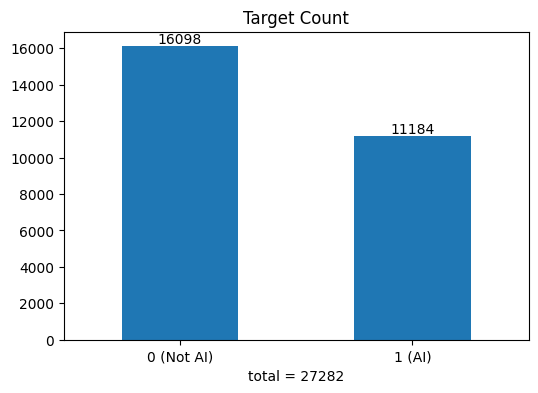

In [ ]:
# Exibição da contagem de targets
count = data['generated'].value_counts()
count.rename(index={0: '0 (Not AI)', 1: '1 (AI)'}, inplace=True)
plt.figure(figsize=(6, 4))

ax = count.plot(kind='bar')
for i, v in enumerate(count):
    ax.text(i, v + 0.1, str(v), ha='center', va='bottom', fontsize=10)

plt.xticks(rotation=0)
plt.title('Target Count')
plt.xlabel(f'total = {len(data)}')
plt.show()

Assim, encerramos o pré-processamento do *Dataset* com um total de **27.282 textos**, com uma quantidade majoritária de elementos **não gerados por LLM**. Após o processamento no tópico seguinte, todos os textos serão divididos para *Treinamento*, *Validação* e *Teste*.

<a name="4."></a>
## **4. Processamento do Dataset**

Nessa etapa, prepararemos os *DataLoaders* do *Pytorch* com um **tokenizador** e com as devidas **features**.

Serão desenvolvidos os seguintes subtópicos:

- [***4.1. Definições***](#4.1.);
- [***4.2. Tokenização e Extração de Features***](#4.2.);
- [***4.3. Splits e DataLoaders***](#4.3.).

<a name="4.1."></a>
### *4.1. Definições*

Nesse subtópico, além de definir as funções que serão utilizadas para o processamento dos textos e a classe para o *Dataset* em si, definimos também o tamanho máximo de *tokens*, *tamanho do batch* e *tokenizador*. Esse último, responsável por mapear o texto para tokens, deve ser definido junto ao modelo de *backbone* que será utilizado futuramente, por questões de compatibilidade.

Entretanto, a escolha do *backbone* `roberta-base` será justificade somente no tópico [**5. Modelo Transformador**](#5.).

In [ ]:
MODEL_NAME = "roberta-base" # Modelo pré-treinado para tokenizador e backbone
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
max_len = 256 # Máximo de tokens
batch_size = 8 # Tamanho dos lotes de treino

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [ ]:
# Normalização do texto
def normalize_text(t):
    t = unicodedata.normalize("NFKC", str(t))
    t = re.sub(r'\s+', ' ', t).strip()
    return t

# Compressão do texto
def compression_ratio(text):
    b = text.encode('utf-8')
    return len(zlib.compress(b)) / max(1, len(b))

# "Entropia" de Tokens
def entropy_of_tokens(tokens):
    if not tokens: return 0.0
    counts = Counter(tokens)
    total = len(tokens)
    return -sum((c/total) * math.log2(c/total) for c in counts.values())

# Extração de features do texto
def extract_features(text):
    t = normalize_text(text)
    tokens = t.split()
    sents = [s.strip() for s in re.split(r'(?<=[.!?])\s+', t) if s.strip()]
    puncts = {p: t.count(p) for p in ['.', ',', ';', ':', '!', '?', '"', "'", '-', '—']}
    feats = {}
    feats['chars'] = len(t)
    feats['tokens'] = len(tokens)
    feats['sentences'] = len(sents)
    feats['avg_token_len'] = np.mean([len(w) for w in tokens]) if tokens else 0.0
    feats['avg_sentence_len_tokens'] = np.mean([len(s.split()) for s in sents]) if sents else 0.0
    feats['ttr'] = len(set(tokens)) / max(1, len(tokens))
    feats['compression_ratio'] = compression_ratio(t)
    feats['entropy_tokens'] = entropy_of_tokens(tokens)
    feats['upper_start_ratio'] = sum(1 for s in sents if s and s[0].isupper()) / max(1, len(sents))
    # pontuações adicionadas com nomes simples
    for k,v in puncts.items(): feats[f'punct_{ord(k)}'] = v
    return feats

# Montagem do DataFrame de features
def build_feature_table(df, text_col='text'):
    feats_list = [extract_features(t) for t in df[text_col].astype(str).tolist()]
    feats_df = pd.DataFrame(feats_list).fillna(0)
    return feats_df


# Classe para Dataset com tokenização e features
class TextWithFeaturesDataset(Dataset):
    def __init__(self, df_path, feats_npy_path, tokenizer, max_len=256, text_col='text', label_col='generated'):
        self.df = pd.read_parquet(df_path).reset_index(drop=True)
        self.features = np.load(feats_npy_path)
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.text_col = text_col
        self.label_col = label_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        text = str(self.df.loc[idx, self.text_col])
        label = int(self.df.loc[idx, self.label_col])
        feats = self.features[idx].astype(np.float32)
        enc = self.tokenizer(text, truncation=True, padding='max_length', max_length=self.max_len, return_tensors='pt')
        item = {
            'input_ids': enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'features': torch.tensor(feats, dtype=torch.float),
            'labels': torch.tensor(label, dtype=torch.long)
        }
        return item

<a name="4.2."></a>
### *4.2. Tokenização e Extração de Features*

Aqui, com o auxílio das funções definidas anteriormente, vamos extrair as *features* dos textos, mapeando as mesmas para um *DataFrame*.

In [ ]:
# Extrai e concatena as features ao DataFrame
feats_list = [extract_features(t) for t in data['text'].astype(str).tolist()]
feats_df = pd.DataFrame(feats_list).fillna(0)
data = pd.concat([data.reset_index(drop=True), feats_df.reset_index(drop=True)], axis=1)
data = data.drop(columns=['text_norm_for_dedupe']) # remove a coluna auxiliar

 # Lista de features que serão utilizadas
feature_cols = feats_df.columns.tolist()
print(f"Features: {feature_cols}")

Features: ['chars', 'tokens', 'sentences', 'avg_token_len', 'avg_sentence_len_tokens', 'ttr', 'compression_ratio', 'entropy_tokens', 'upper_start_ratio', 'punct_46', 'punct_44', 'punct_59', 'punct_58', 'punct_33', 'punct_63', 'punct_34', 'punct_39', 'punct_45', 'punct_8212']


Temos um total de **19 features**, isto é, característias fundamentais dos textos que serão passadas ao modelo junto de seus textos correspondentes a fim de destacar sua importância neles, sendo a maioria relacionado a elementos de pontuação.

<a name="4.3."></a>
### *4.3. Splits e DataLoaders*

Seguimos adiante com o *splitting* do *DataFrame* e de outros subconjuntos importantes, criando cópias em memória.

In [ ]:
# Splits (70/10/20)
train_df, test_df = train_test_split(data, test_size=0.20, stratify=data['generated'], random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.125, stratify=train_df['generated'], random_state=42)
print(f"sizes: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")

# Salvar splits
train_df.to_parquet("train_df_dedup.parquet", index=False)
val_df.to_parquet("val_df_dedup.parquet", index=False)
test_df.to_parquet("test_df_dedup.parquet", index=False)

sizes: train=19096, val=2729, test=5457


In [ ]:
# Fit scaler nas features
scaler = StandardScaler()
X_train_feats = scaler.fit_transform(train_df[feature_cols].values)
X_val_feats   = scaler.transform(val_df[feature_cols].values)
X_test_feats  = scaler.transform(test_df[feature_cols].values)

# Salvar arrays alinhados
joblib.dump(scaler, "scaler.joblib")
np.save("train_feats.npy", X_train_feats)
np.save("val_feats.npy", X_val_feats)
np.save("test_feats.npy", X_test_feats)

In [ ]:
# Criação dos Datasets
train_ds = TextWithFeaturesDataset("train_df_dedup.parquet", "train_feats.npy", tokenizer, max_len=max_len)
val_ds   = TextWithFeaturesDataset("val_df_dedup.parquet", "val_feats.npy", tokenizer, max_len=max_len)
test_ds  = TextWithFeaturesDataset("test_df_dedup.parquet", "test_feats.npy", tokenizer, max_len=max_len)

# Criação dos DataLoaders
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=batch_size*2, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=batch_size*2, shuffle=False, num_workers=2)

Aqui, obtemos os nossos *DataLoaders* de **Treinamento** (70%), **Validação** (10%) e **Teste** (20%), e podemos seguir para o **Transformador**.

<a name="5."></a>
## **5. Modelo Transformador**

Nesse tópico, vamos criar e treinar o nosso modelo Transformador para previsão de *labels*, com base nos *DataLoaders* definidos anteriormente. Para isso, vamos utilizar a seguinte arquitetura:

- **Backbone:** Será um modelo pré-treinado do Pytorch, o **RoBERTa**, conhecido por ser um modelo forte em tarefas de classificação e possuir um tokenizador robusto para pontuação [²](#8.);
- **Classificador:** Será uma rede sequencial de uma camada com 256 neurônios, recebendo um número de entradas que depende do número de *features* extraídas.

Além disso, também definimos a função de avaliação, que calculará a métrica `auc` [³](#8.), a qual mede o quão bem o modelo separa as duas classes por meio de um ranking (1.0 = perfeito; 0.5 = aleatório). Ela será, ao lado da *loss*, uma das métricas de desempenho da rede.

Como otimizador, utilizaremos o `AdamW`, junto a um *learning rate* adaptativo (*scheduler*), e, como função de perda, `CrossEntropyLoss`.

<a name="5.1."></a>
### *5.1. Definições*

Aqui, definimos a arquitetura de modelo e a função de avaliação:

In [ ]:
# Modelo Transformador
class TransformerWithFeatures(nn.Module):
  def __init__(self, model_name, n_features, n_classes=2, dropout=0.2):
    super().__init__()
    self.backbone = AutoModel.from_pretrained(model_name)
    hidden_size = self.backbone.config.hidden_size
    self.classifier = nn.Sequential(
      nn.Linear(hidden_size + n_features, 256),
      nn.ReLU(),
      nn.Dropout(dropout),
      nn.Linear(256, n_classes)
    )

  def forward(self, input_ids, attention_mask, features):
    out = self.backbone(input_ids=input_ids, attention_mask=attention_mask, return_dict=True)
    if hasattr(out, 'pooler_output') and out.pooler_output is not None:
      cls = out.pooler_output
    else:
      cls = out.last_hidden_state[:,0,:]
    x = torch.cat([cls, features], dim=1)
    logits = self.classifier(x)
    return logits


# Função para avaliação durante o treinamento
def evaluate(loader):
  model.eval()
  preds, trues, probs = [], [], []
  with torch.no_grad():
    for b in loader:
      input_ids = b['input_ids'].to(device)
      attention_mask = b['attention_mask'].to(device)
      feats = b['features'].to(device)
      labels = b['labels'].to(device)
      logits = model(input_ids=input_ids, attention_mask=attention_mask, features=feats)
      p = torch.softmax(logits, dim=1)[:,1].detach().cpu().numpy()
      y_pred = logits.argmax(dim=1).cpu().numpy()
      preds.extend(y_pred.tolist())
      probs.extend(p.tolist())
      trues.extend(labels.cpu().numpy().tolist())
  report = classification_report(trues, preds, digits=4)
  auc = roc_auc_score(trues, probs)
  return report, auc, [trues, preds, probs]

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_features = X_train_feats.shape[1]
model = TransformerWithFeatures(MODEL_NAME, n_features).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
epochs = 3
total_steps = len(train_loader) * epochs
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0.05*total_steps, num_training_steps=total_steps)
criterion = nn.CrossEntropyLoss()

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Acima, definimos os parâmetros restantes antes do treinamento e inicializamos o objeto na arquitetura definida.

<a name="5.2."></a>
### *5.2. Treinamento do Modelo*

Iniciaremos aqui o *fine-tuning* da nossa rede, por três épocas.

In [ ]:
# Loop de treinamento
best_val_auc = 0.0
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        feats = batch['features'].to(device)
        labels = batch['labels'].to(device)
        logits = model(input_ids=input_ids, attention_mask=attention_mask, features=feats)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        running_loss += loss.item()
    avg_loss = running_loss / len(train_loader)
    val_report, val_auc, _ = evaluate(val_loader)
    print(f"Epoch {epoch+1}/{epochs} - loss: {avg_loss:.4f} - val_auc: {val_auc:.4f}")
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.state_dict(), "best_model.pt")
        print("Saved best_model.pt")

Epoch 1/3 - loss: 0.0768 - val_auc: 0.9995
Saved best_model.pt
Epoch 2/3 - loss: 0.0148 - val_auc: 1.0000
Saved best_model.pt
Epoch 3/3 - loss: 0.0030 - val_auc: 1.0000
Saved best_model.pt


Perceba que o treinamento parece ter apresentado um desempenho **quase perfeito**, com um *auc* de validação máximo, o que aponta para a possível existência de irregularidades no conjunto original de dados, conforme abordaremos adiante.

<br>

Agora, seguiremos para a avaliação do modelo no conjunto de testes e observação/análise dos resultados.

<a name="6."></a>
## **6. Avaliação e Resultados**

Aqui, vamos realizar as avaliações sobre o conjunto dedicado de testes, e desenvolver uma breve análise e levantamento de hipóteses.

Este tópico está dividido da seguinte forma:

- [***6.1. Predição no Conjunto de Teste***](#6.1.);
- [***6.2. Erros de Predição***](#6.2.);
- [***6.3. Análise e Hipóteses***](#6.3.).

<a name="6.1."></a>
### *6.1. Predição no Conjunto de Teste*

Vamos começar a avaliação importando o arquivo do melhor modelo salvo, e passando para ele o nosso *DataLoader* de teste, com 20% do número de elementos do *Dataset* original. Para essa avaliação, vamos observar o **AUC** e o **Classification Report**.

In [ ]:
# Carregar o melhor modelo
model.load_state_dict(torch.load("best_model.pt"))

# Obter AUC e Classification Report
test_report, test_auc, arrays = evaluate(test_loader)
print("Test AUC:", test_auc, '\n')
print(test_report)

Test AUC: 0.9999940303811949 

              precision    recall  f1-score   support

           0     0.9997    0.9947    0.9972      3220
           1     0.9925    0.9996    0.9960      2237

    accuracy                         0.9967      5457
   macro avg     0.9961    0.9971    0.9966      5457
weighted avg     0.9967    0.9967    0.9967      5457



Observe que, assim como no *fine-tuning*, o modelo apresentou desempenho muito alto na predição do conjunto de teste.

<a name="6.2."></a>
### *6.2. Erros de Predição*

Nesse subtópico, geraremos uma tabela com os (18 de 5457) erros de predição, junto das probabilidades que levaram a rede ao erro.

In [ ]:
df_test = pd.read_parquet("test_df_dedup.parquet").reset_index(drop=True) # Recupera o DataFrame de Teste
df_preds = pd.DataFrame({'text': df_test['text'], 'real': arrays[0], 'pred': arrays[1], 'prob': arrays[2]}) # Monta um novo DataFrame

In [ ]:
#data_table.DataTable(df_preds, num_rows_per_page=3) # Mostrar todas as predições em Test
data_table.DataTable(df_preds[df_preds.real != df_preds.pred], num_rows_per_page=3) # Mostrar as predições erradas em Test

,text,real,pred,prob
270,Is it possible to explore Venus? Venus is know...,0,1,0.998931
395,"Yes, I agree that most advertisements make pro...",1,0,0.001144
539,Some people can tell wheather someone is happy...,0,1,0.999887
676,There are many advantages to limiting car usag...,0,1,0.995077
1295,"In America, cars are concidered an important n...",0,1,0.999037
1853,"""Advice leads to experience, experience leads ...",0,1,0.994174
1981,"In some societies, students are expected to id...",0,1,0.999662
2040,Automobiles have proved to be very convenient ...,0,1,0.638844
2419,"Dear Senator,\n\nI am writing this letter to i...",0,1,0.999770
3116,Some people think that when they master at som...,0,1,0.957526


***Obs:** as probabilidades, em sua maioria, apesar de muito próximas de 0 ou de 1, ainda estão "distantes" desses valores se comparadas com aquelas dos casos de acerto. Ou seja, podemos inferir que, nos casos de erro, o modelo teve "um pouco menos" de certeza sobre a sua resposta.*

<a name="6.3."></a>
### *6.3. Análise e Hipóteses*

Foi possível observar, tanto pelas métricas do treinamento quanto pela avaliação do conjunto de testes, que o modelo pareceu apresentar uma excelente performance, com um valor de *AUC* que pode ser aproximado para 1 (que representaria um modelo perfeito). Entretanto, casos como esse geralmente apontam para algum tipo de irregularidade, seja ela durante o treinamento (*overfitting*) ou seja ela com o próprio *conjunto de dados cru*. Nesse caso, vale ressaltar que houve um pré-processamento para limpar duplicatas do *DataFrame*.

Porém, como mencionado na breve análise inicial do *Dataset*, alguns temas se repetem em muitos dos textos. Esse fator impulsiona a probabilidade de que alguns destes apresentem trechos repetidos, especialmente quando foram, de fato, gerados por um modelo de linguagem. Isso significa que, nessa hipótese, podem haver textos muito semelhantes no conjunto, mas que não teriam sido ajustados pelo pré-processamento por não serem iguais, o que pode levar ao enviesamento dos próprios *DataLoaders* utilizados.

Essa é uma possível interpretação para o resultado irreal tanto de *loss* quanto de *AUC*. Mas vale ressaltar que, mesmo com esse contexto, já se esperava que o modelo trouxesse um resultado ótimo, por fatores como utilizar um *backbone* pré-treinado, trazer o conjunto de *features* extraídos à parte, e apresentar um grande número de amostras. Ou seja, não é incorreto assumir que houve um comportamento satifatório por parte do modelo, uma vez que mostrou resultados positivos na própria predição de teste.

<a name="7."></a>
## **7. Conclusão**

Após uma série de etapas de processamento do *Dataset*, que envolveu desde a limpeza de duplicatas até a tokenização dos textos e a extração de *features*, foi elaborada uma arquitetura de **Transformador** que utilizou um *backbone* pré-treinado e um "pequeno" *fine-tuning* para julgar se houve ou não a utilização de LLM's na geração de redações em inglês.

Durante o treinamento e avaliação, observou-se que houve um desempenho irreal, e que apontava para alguma irregularidade. Supõe-se que a mesma é advinda de uma eventual coincidência de trechos em muitas das redações que compartilham do mesmo tema, o que pode enviesar os conjuntos utilizados para validar e testar a rede. Entretanto, mesmo com essa hipótese sendo um cenário real, o modelo desenvolvido apresentou um comportamento próximo do esperado no contexto em que foi desenvolvido.

<a name="8."></a>
## **8. Referências**

[[1]](#8.) **LLM - Detect AI Generated Text Dataset.** *kaggle*. Disponível em: *https://www.kaggle.com/datasets/sunilthite/llm-detect-ai-generated-text-dataset*

[[2]](#8.) LIU, Yinhan et al. **RoBERTa: A Robustly Optimized BERT Pretraining Approach.** Disponível em: *https://arxiv.org/pdf/1907.11692*. Acesso em: 12 dez. 2025.

[[3]](#8.) **roc_auc_score.** *scikit-learn.* Disponível em: *https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html*.